# MIMO Detection Pipeline

Interactive walkthrough of the MIMO detection pipeline:

$$\min_{x \in \{-1,+1\}^n}~\|Ax - b\|^2$$

The channel matrix $A \in \mathbb{C}^{m \times n}$ is **fixed** (estimated once). The problem parameter is
the received signal $b \in \mathbb{C}^m$, represented as a real $2m$-vector by stacking real and imaginary parts.
Here $n = 2$ transmitters, $m = 4$ receivers (input dimension $2m = 8$).

Each section corresponds to one pipeline stage (`scripts/generate_mimo_data.py`,
`scripts/train_mimo.py`, `scripts/evaluate_results.py`, `scripts/certify_mimo.py`).

## Setup

In [1]:
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold

PROJECT_ROOT = pathlib.Path(".").resolve().parents[0]
sys.path.insert(0, str(PROJECT_ROOT))

from problems.mimo_detection.problem import (
    solve_relaxation, solve_local,
    _build_sdp_problem, A_COMPLEX, A_REAL, M_RECEIVERS, N_TRANSMITTERS,
)
from problems.mimo_detection.generate_data import sample_parameters, _B_COLS
from nn.models import DNN
from nn.training import train_model_two_phase, predict, save_model
from nn.metrics import error_summary, optimality_confusion_matrix

print(f"Channel matrix H: {M_RECEIVERS} receivers x {N_TRANSMITTERS} transmitters (complex)")
print(f"Input dimension (2m): {2 * M_RECEIVERS}")

Channel matrix H: 4 receivers x 2 transmitters (complex)
Input dimension (2m): 8


## Stage 1: Generate labeled data

Sample received signals $b = Ax + w$ (with $x \sim \text{Uniform}(\{-1,+1\}^n)$ and noise $w \sim \sigma \mathcal{CN}(0, I)$)
and label each with the SDP relaxation's optimal value — a valid lower bound on $\|Ax^* - b\|^2$.

In [2]:
N_SAMPLES = 30000
SIGMA_SQ = 0.2
SEED = 0

sample_args = {"sigma_sq": SIGMA_SQ, "seed": SEED}
P = sample_parameters(N_SAMPLES, args=sample_args)  # (N, 2m)

prob, M_param, Z = _build_sdp_problem()
relax_args = {"prob": prob, "M_param": M_param, "Z": Z}

costs, exact_flags = [], []
for p in P:
    value, result = solve_relaxation(p, args=relax_args)
    costs.append(value)
    exact_flags.append(result["exact"])

df_data = pd.DataFrame(P, columns=_B_COLS)
df_data["Cost"] = costs
df_data["Exact"] = exact_flags

print(f"Generated {len(df_data)} samples ({df_data['Exact'].sum()} exact, "
      f"{(~df_data['Exact']).sum()} inexact)")
print(f"Relaxation cost: mean={df_data['Cost'].mean():.4f}, "
      f"std={df_data['Cost'].std():.4f}, "
      f"min={df_data['Cost'].min():.4f}, max={df_data['Cost'].max():.4f}")
df_data.head()

Generated 30000 samples (28424 exact, 1576 inexact)
Relaxation cost: mean=1.5964, std=0.7890, min=0.0505, max=7.2883


,b0,b1,b2,b3,b4,b5,b6,b7,Cost,Exact
0,0.932072,-1.849580,0.331679,-1.190716,0.765543,1.023796,0.824737,0.887614,1.030316,True
1,0.511401,1.575742,0.983615,-0.278620,0.322837,0.490979,-0.440849,-0.192704,1.644024,True
2,-0.826906,1.361575,-0.566459,0.243309,-1.159142,-1.515371,-1.051693,-0.850959,1.630704,True
3,-1.717569,1.843669,-0.689801,1.037328,-0.526532,-0.729624,-1.016007,-1.554072,1.398925,True
4,-0.612786,-0.594574,-0.760495,-0.657369,-0.358675,-0.181443,0.708083,0.231350,0.986438,True


### Visualize the relaxation cost distribution

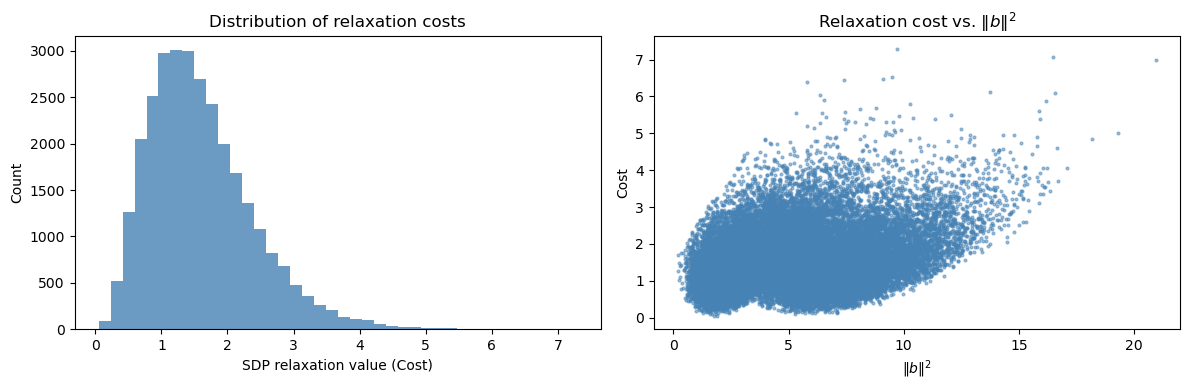

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cost histogram
axes[0].hist(df_data["Cost"], bins=40, color="steelblue", alpha=0.8)
axes[0].set_xlabel("SDP relaxation value (Cost)")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of relaxation costs")

# Cost vs. ||b||^2 (a natural scale for the problem)
b_norm_sq = (P ** 2).sum(axis=1)
axes[1].scatter(b_norm_sq, df_data["Cost"], s=4, alpha=0.5, color="steelblue")
axes[1].set_xlabel(r"$\|b\|^2$")
axes[1].set_ylabel("Cost")
axes[1].set_title(r"Relaxation cost vs. $\|b\|^2$")

plt.tight_layout()
plt.show()

### (Optional) Save dataset to disk

In [4]:
DATA_DIR = PROJECT_ROOT / "data" / "mimo_detection"
DATA_DIR.mkdir(parents=True, exist_ok=True)

data_path = DATA_DIR / f"training_MIMO_{N_SAMPLES}samples.csv"
df_data.to_csv(data_path, index=False)
print(f"Saved to {data_path}")

Saved to /Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/data/mimo_detection/training_MIMO_30000samples.csv


## Stage 2: Train a DNN with two-phase training + k-fold cross-validation

Phase 1 (pre-training): large batch + large LR for fast convergence to a good basin.  
Phase 2 (fine-tuning): small batch + small LR to settle into a flat, well-generalizing minimum.

Tweak `HIDDEN_DIMS`, `N_SPLITS`, and the per-phase hyperparameters below.

In [80]:
# --- Parameters to play with ---
HIDDEN_DIMS = (256, 256)
N_SPLITS = 2

PRETRAIN_EPOCHS     = 500
PRETRAIN_LR         = 1e-2
PRETRAIN_BATCH_SIZE = 512

FINETUNE_EPOCHS     = 100
FINETUNE_LR         = 1e-4
FINETUNE_BATCH_SIZE = 64
# --------------------------------

X_arr = df_data[_B_COLS].values
y_arr = df_data["Cost"].values
input_dim = 2 * M_RECEIVERS

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_arr)):
    print(f"\n--- Fold {fold} ---")
    model = DNN(input_dim=input_dim, hidden_dims=HIDDEN_DIMS)
    model, train_history, test_history = train_model_two_phase(
        model,
        X_arr[train_idx], X_arr[test_idx],
        y_arr[train_idx], y_arr[test_idx],
        pretrain_epochs=PRETRAIN_EPOCHS,
        pretrain_lr=PRETRAIN_LR,
        pretrain_batch_size=PRETRAIN_BATCH_SIZE,
        finetune_epochs=FINETUNE_EPOCHS,
        finetune_lr=FINETUNE_LR,
        finetune_batch_size=FINETUNE_BATCH_SIZE,
        verbose=True,
    )
    y_pred = predict(model, X_arr[test_idx])
    fold_results.append(dict(
        fold=fold,
        model=model,
        train_history=train_history,
        test_history=test_history,
        phase_boundary=PRETRAIN_EPOCHS,
        y_true=y_arr[test_idx],
        y_pred=y_pred,
    ))


--- Fold 0 ---


Fine-tuning: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.25it/s]



--- Fold 1 ---


Fine-tuning: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:16<00:00,  6.19it/s]


### Training curves

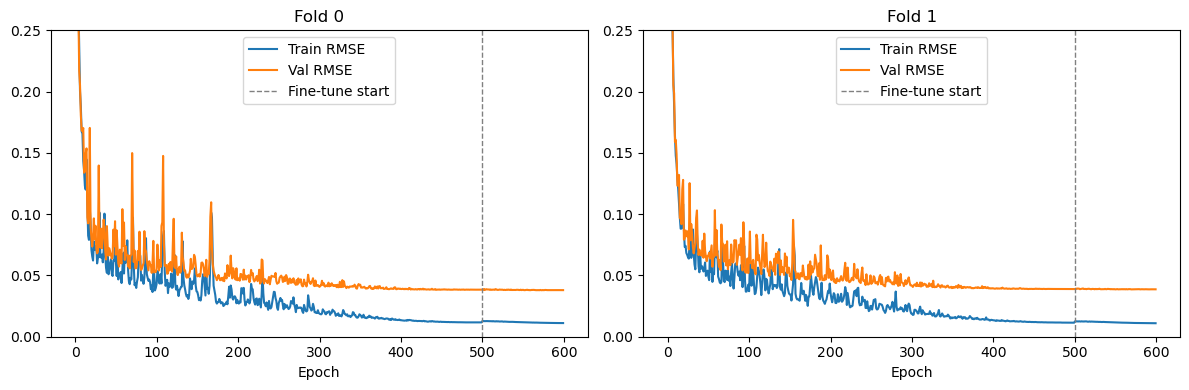

In [82]:
fig, axes = plt.subplots(1, len(fold_results), figsize=(6 * len(fold_results), 4), squeeze=False)
for fold in fold_results:
    ax = axes[0, fold["fold"]]
    ax.plot(np.sqrt(fold["train_history"]), label="Train RMSE")
    ax.plot(np.sqrt(fold["test_history"]),  label="Val RMSE")
    ax.axvline(fold["phase_boundary"], color="gray", linestyle="--", linewidth=1, label="Fine-tune start")
    ax.set_title(f"Fold {fold['fold']}")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.set_ylim(0.0, 0.25)
plt.tight_layout()
plt.show()

### (Optional) Save fold models and out-of-fold predictions

In [83]:
MODEL_DIR = PROJECT_ROOT / "models" / "mimo_detection"
RESULTS_DIR = PROJECT_ROOT / "results" / "mimo_detection"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

pred_dfs = []
for fold in fold_results:
    save_path = MODEL_DIR / f"dnn_MIMO_{N_SAMPLES}samples_fold{fold['fold']}.pth"
    save_model(fold["model"], save_path)
    pred_dfs.append(pd.DataFrame({"fold": fold["fold"], "Cost": fold["y_true"], "Pred": fold["y_pred"]}))

df_preds = pd.concat(pred_dfs, ignore_index=True)
preds_path = RESULTS_DIR / f"cv_predictions_MIMO_{N_SAMPLES}samples.csv"
df_preds.to_csv(preds_path, index=False)
print(f"Saved predictions to {preds_path}")

Saved predictions to /Users/charlesgulian/Desktop/Projects/nn-4-opt-cert/results/mimo_detection/cv_predictions_MIMO_30000samples.csv


## Stage 3: Evaluate prediction error

In [84]:
for fold in fold_results:
    stats = error_summary(fold["y_true"], fold["y_pred"])
    print(
        f"Fold {fold['fold']}: "
        f"mean abs error = {stats['mean_abs_error']:.4f} "
        f"(95% CI: [{stats['ci_lower']:.4f}, {stats['ci_upper']:.4f}]), "
        f"max abs error = {stats['max_abs_error']:.4f} "
        f"(n={stats['n']})"
    )

y_true_all = np.concatenate([fold["y_true"] for fold in fold_results])
y_pred_all = np.concatenate([fold["y_pred"] for fold in fold_results])
overall = error_summary(y_true_all, y_pred_all)
print(
    f"Overall: "
    f"mean abs error = {overall['mean_abs_error']:.4f} "
    f"(95% CI: [{overall['ci_lower']:.4f}, {overall['ci_upper']:.4f}]), "
    f"max abs error = {overall['max_abs_error']:.4f} "
    f"(n={overall['n']})"
)

Fold 0: mean abs error = 0.0254 (95% CI: [0.0250, 0.0259]), max abs error = 0.5250 (n=15000)
Fold 1: mean abs error = 0.0266 (95% CI: [0.0261, 0.0270]), max abs error = 0.5963 (n=15000)
Overall: mean abs error = 0.0260 (95% CI: [0.0257, 0.0263]), max abs error = 0.5963 (n=30000)


### Residual histogram

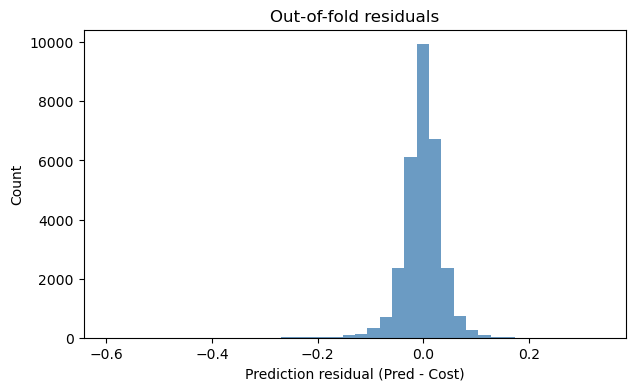

In [85]:
residuals = y_pred_all - y_true_all
plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=40, color="steelblue", alpha=0.8)
plt.xlabel("Prediction residual (Pred - Cost)")
plt.ylabel("Count")
plt.title("Out-of-fold residuals")
plt.show()

## Bonus: Compare DNN prediction vs. ZF detector on a few points

For each test point: SDP relaxation value (true lower bound), ZF detector cost, and DNN prediction.
When ZF is optimal, `LocalCost ≈ Cost`; the DNN aims to predict `Cost`.

In [86]:
import torch

# Use fold 0 model (trained on half the data)
model = fold_results[0]["model"]
model.eval()

print(f"{'b (first 4 dims)':>30}  {'Relaxation':>12}  {'ZF Cost':>10}  {'DNN Pred':>10}")
print("-" * 70)
for i in range(8):
    p = P[i]
    relax_val, _ = solve_relaxation(p, args=relax_args)
    local_val, local_res = solve_local(p)
    with torch.no_grad():
        pred_val = model(torch.tensor(p, dtype=torch.float32).unsqueeze(0)).item()
    b_str = str(np.round(p[:4], 2))
    print(f"{b_str:>30}  {relax_val:>12.4f}  {local_val:>10.4f}  {pred_val:>10.4f}")

              b (first 4 dims)    Relaxation     ZF Cost    DNN Pred
----------------------------------------------------------------------
     [ 0.93 -1.85  0.33 -1.19]        1.0303      1.0303      1.0302
     [ 0.51  1.58  0.98 -0.28]        1.6440      1.6440      1.7127
     [-0.83  1.36 -0.57  0.24]        1.6307      1.6307      1.6399
     [-1.72  1.84 -0.69  1.04]        1.3989      1.3989      1.4435
     [-0.61 -0.59 -0.76 -0.66]        0.9864      0.9864      1.0237
     [ 0.91 -1.24  1.16 -0.98]        1.9489      1.9489      1.9776
     [ 1.28 -0.25  0.32 -0.91]        2.8364      2.8714      2.7195
     [ 0.79 -1.95  0.23 -1.91]        2.7593      2.7593      2.7597


## Stage 4: Certify optimality of the ZF detector

For each test point, we compute:
- `Cost`: SDP relaxation value (ground truth lower bound)
- `LocalCost`: ZF detector's objective value $\|A\hat{x} - b\|^2$
- `Pred`: DNN's prediction of the relaxation value

The ZF solution is *actually optimal* if `|LocalCost - Cost| <= TOL` (relaxation tight).
The DNN *certifies optimality* if `|LocalCost - Pred| <= TOL`.

Tweak `N_TEST_SAMPLES`, `TEST_SEED`, `TEST_SIGMA`, and `TOL`.

In [92]:
# --- Parameters to play with ---
N_TEST_SAMPLES = 5000
TEST_SEED = 1
TEST_SIGMA_SQ = 0.4   # noise variance for test distribution
TOL = 0.5
# --------------------------------

P_test = sample_parameters(N_TEST_SAMPLES, args={"sigma_sq": TEST_SIGMA_SQ, "seed": TEST_SEED})

test_costs, test_local_costs, test_preds = [], [], []
for p in P_test:
    value, _ = solve_relaxation(p, args=relax_args)
    test_costs.append(value)

    local_value, _ = solve_local(p)
    test_local_costs.append(local_value)

    with torch.no_grad():
        pred_value = model(torch.tensor(p, dtype=torch.float32).unsqueeze(0)).item()
    test_preds.append(pred_value)

df_test = pd.DataFrame(P_test, columns=_B_COLS)
df_test["Cost"] = test_costs
df_test["LocalCost"] = test_local_costs
df_test["Pred"] = test_preds

cm = optimality_confusion_matrix(df_test["Cost"], df_test["LocalCost"], df_test["Pred"], tol=TOL)

print(f"Optimality certification (tol={TOL}), n={cm['n']}")
print(f"{'':>20} {'Predicted Optimal':>18} {'Predicted Suboptimal':>22}")
print(f"{'Actually Optimal':>20} {cm['tp']:>18} {cm['fn']:>22}")
print(f"{'Actually Suboptimal':>20} {cm['fp']:>18} {cm['tn']:>22}")
print()
print(f"False positive rate: {cm['fpr']:.4f}")
print(f"False negative rate: {cm['fnr']:.4f}")

Optimality certification (tol=0.5), n=5000
                      Predicted Optimal   Predicted Suboptimal
    Actually Optimal               4574                    114
 Actually Suboptimal                  4                    308

False positive rate: 0.0128
False negative rate: 0.0243


### Effect of noise level on ZF optimality

At low noise (small $\sigma$), ZF finds the exact optimum in most cases — the relaxation gap
is zero and ZF succeeds. At higher noise, ZF degrades while the SDP bound remains valid.
This cell sweeps $\sigma$ to show the fraction of test points where ZF is actually optimal.

sigma_sq=0.01: ZF optimal in 100.0% of samples
sigma_sq=0.05: ZF optimal in 100.0% of samples
sigma_sq=0.10: ZF optimal in 100.0% of samples
sigma_sq=0.20: ZF optimal in 99.5% of samples
sigma_sq=0.50: ZF optimal in 91.5% of samples
sigma_sq=1.00: ZF optimal in 85.5% of samples


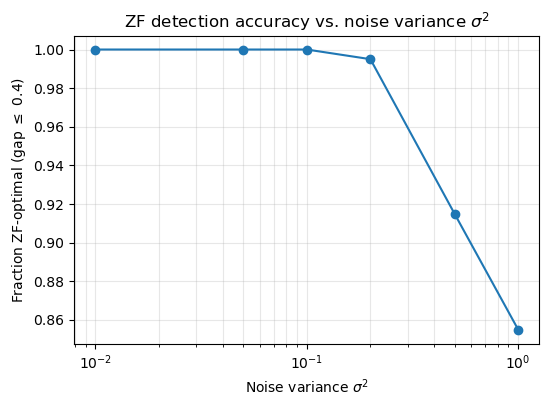

In [88]:
sigma_sq_vals = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
zf_optimal_fracs = []

for sigma_sq in sigma_sq_vals:
    P_s = sample_parameters(200, args={"sigma_sq": sigma_sq, "seed": 42})
    gaps = []
    for p in P_s:
        rv, _ = solve_relaxation(p, args=relax_args)
        lv, _ = solve_local(p)
        gaps.append(abs(lv - rv))
    frac = np.mean(np.array(gaps) <= TOL)
    zf_optimal_fracs.append(frac)
    print(f"sigma_sq={sigma_sq:.2f}: ZF optimal in {100*frac:.1f}% of samples")

plt.figure(figsize=(6, 4))
plt.plot(sigma_sq_vals, zf_optimal_fracs, marker="o")
plt.xlabel(r"Noise variance $\sigma^2$")
plt.ylabel(f"Fraction ZF-optimal (gap $\leq$ {TOL})")
plt.title(r"ZF detection accuracy vs. noise variance $\sigma^2$")
plt.xscale("log")
plt.grid(True, which="both", alpha=0.3)
plt.show()